# Crop Price Prediction — Modeling & Evaluation

This notebook trains and evaluates multiple regression models on the engineered feature dataset (`data/processed/features_dataset.csv`) using a **time-based split** (no shuffling) to avoid data leakage.

## Sections
1. Load Data
2. Time-Based Train/Test Split
3. Train Three Models
4. Evaluate All Models
5. Feature Importance
6. Prediction vs Actual Plot
7. Save Best Model

In [1]:
import json
from datetime import date
from math import sqrt
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# Paths (notebook lives in notebooks/, project root is one level up)
DATASET_PATH = Path("../data/processed/features_dataset.csv")
FEATURE_COLUMNS_PATH = Path("../src/models/feature_columns.json")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../src/models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "price"

## Section 1 — Load Data

- Load `features_dataset.csv` (parse `date`)
- Load feature column names from `src/models/feature_columns.json`
- Print shape and feature columns list
- Print price statistics (mean, min, max, std)

In [2]:
df = pd.read_csv(DATASET_PATH, parse_dates=["date"])

with open(FEATURE_COLUMNS_PATH, "r", encoding="utf-8") as f:
    feature_columns = json.load(f)

print("Dataset shape:", df.shape)
print("\nFeature columns (loaded from JSON):")
print(feature_columns)

price_stats = {
    "mean": float(df[TARGET_COLUMN].mean()),
    "min": float(df[TARGET_COLUMN].min()),
    "max": float(df[TARGET_COLUMN].max()),
    "std": float(df[TARGET_COLUMN].std()),
}
print("\nPrice statistics:")
print(price_stats)

display(df.head())

Dataset shape: (6353, 25)

Feature columns (loaded from JSON):
['commodity_encoded', 'market_encoded', 'admin1_encoded', 'pricetype_encoded', 'category_encoded', 'year', 'month', 'quarter', 'is_harvest_season', 'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'price_rolling_mean_3', 'price_rolling_std_3', 'price_rolling_mean_6']

Price statistics:
{'mean': 308.86736187627895, 'min': 54.02, 'max': 1645.58, 'std': 174.94159444781778}


,date,admin1,admin2,market,category,commodity,unit,pricetype,price,year,...,category_encoded,price_lag_1,price_lag_3,price_lag_6,price_lag_12,price_rolling_mean_3,price_rolling_std_3,price_rolling_mean_6,quarter,is_harvest_season
0,2016-11-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,228.31,2016,...,0,228.31,172.47,121.17,56.46,222.406667,10.224873,187.555000,4,1
1,2016-12-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,228.31,2016,...,0,228.31,210.60,113.17,53.66,228.310000,0.000000,206.745000,4,1
2,2017-01-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,248.85,2017,...,0,228.31,228.31,172.47,121.17,235.156667,11.858775,219.475000,1,1
3,2017-02-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,269.41,2017,...,0,248.85,228.31,172.47,121.17,248.856667,20.550001,235.631667,1,1
4,2021-06-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,484.38,2021,...,0,269.41,228.31,210.60,121.17,334.213333,130.453820,281.261667,2,0


## Section 2 — Time-Based Train/Test Split

- Sort by date (ascending)
- Use the **last 20%** of rows as the test set (no shuffle)
- Split into X/y using the feature columns list
- Print train/test sizes and date ranges to confirm no leakage

In [3]:
df = df.sort_values("date", ascending=True).reset_index(drop=True)

n_total = len(df)
n_test = int(np.ceil(n_total * 0.2))
n_train = n_total - n_test

train_df = df.iloc[:n_train].copy()
test_df = df.iloc[n_train:].copy()

X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET_COLUMN].copy()
X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET_COLUMN].copy()

train_min_date = train_df["date"].min().date().isoformat()
train_max_date = train_df["date"].max().date().isoformat()
test_min_date = test_df["date"].min().date().isoformat()
test_max_date = test_df["date"].max().date().isoformat()

print(f"Total rows: {n_total}")
print(f"Train rows: {len(train_df)} | Date range: {train_min_date} to {train_max_date}")
print(f"Test rows : {len(test_df)} | Date range: {test_min_date} to {test_max_date}")

Total rows: 6353
Train rows: 5082 | Date range: 2003-01-15 to 2022-05-15
Test rows : 1271 | Date range: 2022-05-15 to 2023-01-15


## Section 3 — Train Three Models

Train:
- Linear Regression
- Decision Tree (`max_depth=10, random_state=42`)
- Random Forest (`n_estimators=100, random_state=42, n_jobs=-1`)

In [4]:
models = {}

print("Training Linear Regression...")
models["Linear Regression"] = LinearRegression()
models["Linear Regression"].fit(X_train, y_train)
print("Done.")

print("\nTraining Decision Tree...")
models["Decision Tree"] = DecisionTreeRegressor(max_depth=10, random_state=42)
models["Decision Tree"].fit(X_train, y_train)
print("Done.")

print("\nTraining Random Forest...")
models["Random Forest"] = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
models["Random Forest"].fit(X_train, y_train)
print("Done.")

Training Linear Regression...
Done.

Training Decision Tree...
Done.

Training Random Forest...


Done.


## Section 4 — Evaluate All Models

Compute on `X_test, y_test`:
- MAE
- RMSE
- R²

Print a clean comparison table and the winner for each metric.

In [5]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"mae": mae, "rmse": rmse, "r2": r2}

# Print comparison table
header = f"{'Model':<23} | {'MAE':<8} | {'RMSE':<8} | {'R²':<6}"
sep = "-" * len(header)
print(header)
print(sep)
for name in ["Linear Regression", "Decision Tree", "Random Forest"]:
    m = results[name]
    print(f"{name:<23} | {m['mae']:<8.2f} | {m['rmse']:<8.2f} | {m['r2']:<6.3f}")

# Winners per metric
winner_mae = min(results.items(), key=lambda x: x[1]["mae"])[0]
winner_rmse = min(results.items(), key=lambda x: x[1]["rmse"])[0]
winner_r2 = max(results.items(), key=lambda x: x[1]["r2"])[0]

print("\nWinners:")
print("- Best MAE :", winner_mae)
print("- Best RMSE:", winner_rmse)
print("- Best R²  :", winner_r2)

best_model_name = winner_rmse
best_model = models[best_model_name]
print("\nBest model selected by RMSE:", best_model_name)

Model                   | MAE      | RMSE     | R²    
------------------------------------------------------
Linear Regression       | 17.03    | 29.31    | 0.980 
Decision Tree           | 23.60    | 57.42    | 0.921 
Random Forest           | 16.96    | 33.92    | 0.973 

Winners:
- Best MAE : Random Forest
- Best RMSE: Linear Regression
- Best R²  : Linear Regression

Best model selected by RMSE: Linear Regression


## Section 5 — Feature Importance

Compute and plot Random Forest feature importances and save to `data/processed/plot5_feature_importance.png`.

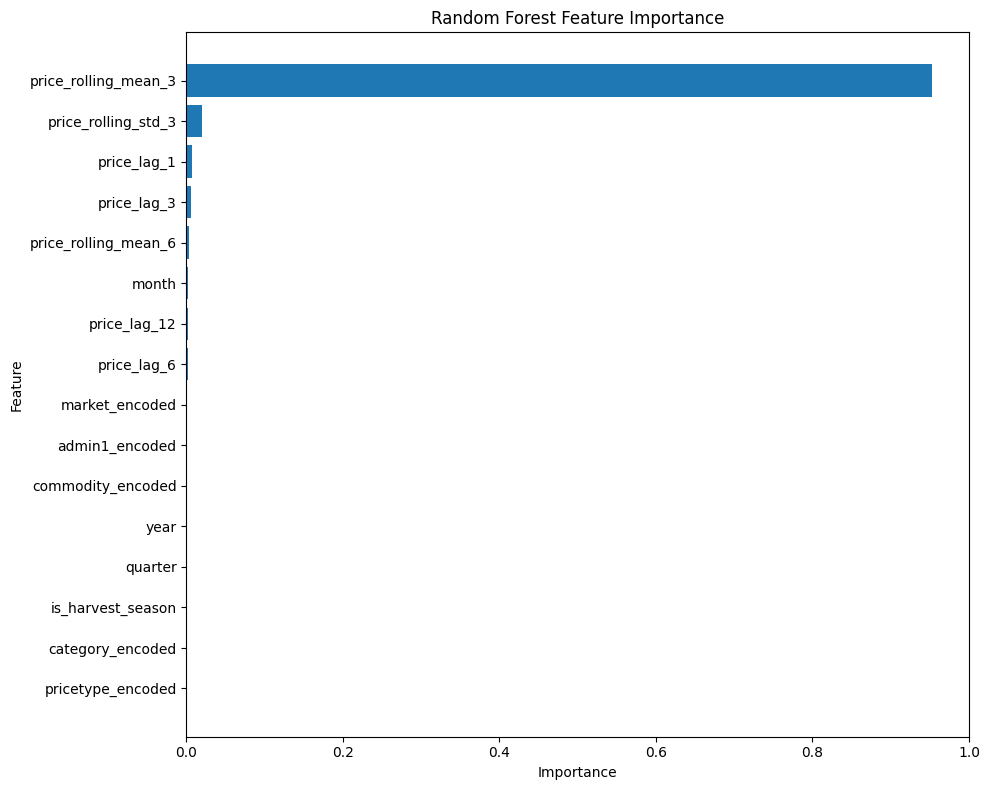

Feature importance plot saved to: ..\data\processed\plot5_feature_importance.png


In [6]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

fi = pd.DataFrame({"feature": feature_columns, "importance": importances}).sort_values(
    "importance", ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(fi["feature"], fi["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plot5_path = PROCESSED_DIR / "plot5_feature_importance.png"
plt.savefig(plot5_path, bbox_inches="tight")
plt.show()

print(f"Feature importance plot saved to: {plot5_path}")

## Section 6 — Prediction vs Actual Plot

Use the best model (by RMSE) to generate predictions on the test set, and save the plot to `data/processed/plot6_predicted_vs_actual.png`.

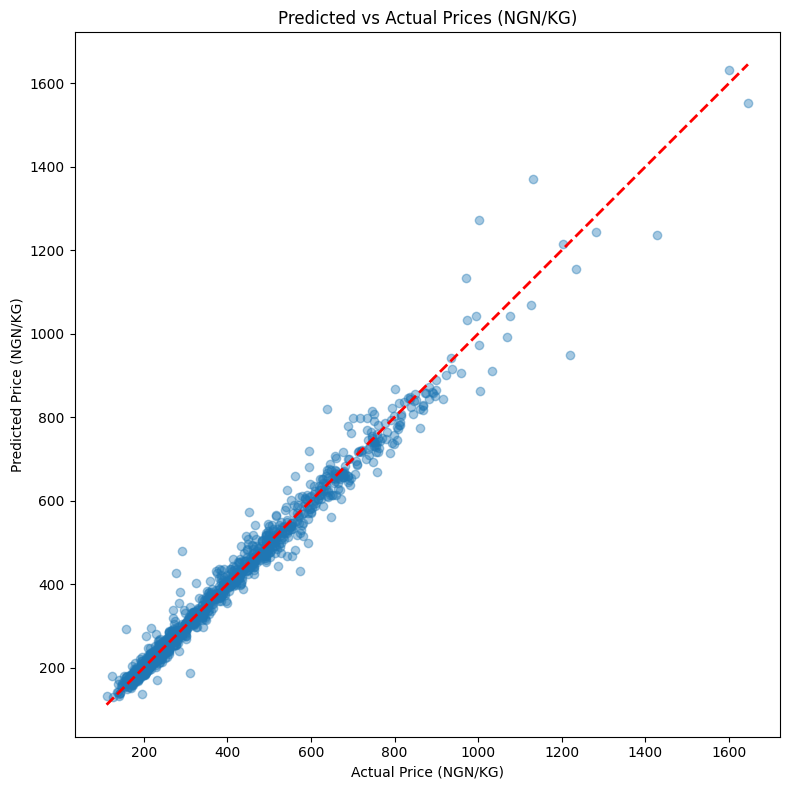

Predicted vs Actual plot saved to: ..\data\processed\plot6_predicted_vs_actual.png


In [7]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.4)

min_val = float(min(y_test.min(), y_pred_best.min()))
max_val = float(max(y_test.max(), y_pred_best.max()))
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.title("Predicted vs Actual Prices (NGN/KG)")
plt.xlabel("Actual Price (NGN/KG)")
plt.ylabel("Predicted Price (NGN/KG)")
plt.tight_layout()

plot6_path = PROCESSED_DIR / "plot6_predicted_vs_actual.png"
plt.savefig(plot6_path, bbox_inches="tight")
plt.show()

print(f"Predicted vs Actual plot saved to: {plot6_path}")

## Section 7 — Save Best Model

- Select best model by lowest RMSE
- Save to `src/models/best_model.joblib`
- Save metadata to `src/models/model_metadata.json`
- Print confirmation messages

In [8]:
best_metrics = results[best_model_name]

best_model_path = MODELS_DIR / "best_model.joblib"
joblib.dump(best_model, best_model_path)

metadata = {
    "model_name": best_model_name,
    "mae": float(best_metrics["mae"]),
    "rmse": float(best_metrics["rmse"]),
    "r2": float(best_metrics["r2"]),
    "train_size": int(len(train_df)),
    "test_size": int(len(test_df)),
    "train_date_range": [train_min_date, train_max_date],
    "test_date_range": [test_min_date, test_max_date],
    "feature_columns": feature_columns,
    "trained_on": date.today().isoformat(),
}

metadata_path = MODELS_DIR / "model_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved best model to:", best_model_path)
print("Saved metadata to:", metadata_path)
print("\nMetadata summary:")
print(metadata)

Saved best model to: ..\src\models\best_model.joblib
Saved metadata to: ..\src\models\model_metadata.json

Metadata summary:
{'model_name': 'Linear Regression', 'mae': 17.0307447248985, 'rmse': 29.30636077905822, 'r2': 0.9795299553963879, 'train_size': 5082, 'test_size': 1271, 'train_date_range': ['2003-01-15', '2022-05-15'], 'test_date_range': ['2022-05-15', '2023-01-15'], 'feature_columns': ['commodity_encoded', 'market_encoded', 'admin1_encoded', 'pricetype_encoded', 'category_encoded', 'year', 'month', 'quarter', 'is_harvest_season', 'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'price_rolling_mean_3', 'price_rolling_std_3', 'price_rolling_mean_6'], 'trained_on': '2026-04-06'}
